# Feature experiment — does spaCy-based matching beat plain whole-word overlap?

**Follow-up to** `terms_overlap.ipynb` (branch `wf-feature-terms-overlap`), which built a
per-paper whole-word overlap feature against each use case's own `terms_must_include` /
`terms_nice_to_have` / `terms_exclude` lists and found real signal on 3 of 6 use cases
(full-population ROC-AUC: `cement_binders` 0.801, `carbon_capture` 0.709, `ner` 0.698) and
none on the other 3 (`soil_microbiome` 0.504, `solar_leo` 0.464, `tech_forecasting`
0.563).

**Question this notebook asks:** does spaCy give a real improvement over plain
whole-word regex matching — either rescuing the 3 dead use cases, or meaningfully
lifting the 3 that already work? Same data, same labelled subset (`triage_label` in
{positive, negative}), same full-population ROC-AUC methodology as the parent notebook —
so every number below is directly comparable to the numbers above.

Four techniques are tested for real; a fifth (semantic/word-vector similarity) is
scoped but explicitly **not** built — see §6 for why.

In [1]:
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
from scipy import stats
from sklearn.metrics import roc_auc_score

DATA_PATH = "../../data/processed/papers_combined.parquet"

# Same visual convention as terms_overlap.ipynb / notebooks/experiments/*.ipynb (validated
# categorical palette — blue/red as two fixed categorical slots, reused here for
# "baseline" vs "spaCy method" rather than positive/negative).
BASELINE_COLOR = "#2a78d6"   # categorical slot 1 (blue)
SPACY_COLOR = "#e34948"      # categorical slot 2 (red)

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "text.color": "#0b0b0b",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "font.size": 10,
})

df = pd.read_parquet(DATA_PATH).reset_index(drop=True)
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns from {DATA_PATH}")
print(f"use cases: {sorted(df['use_case_key'].unique())}")

nlp = spacy.load("en_core_web_sm", disable=["ner"])  # NER itself isn't used here — tokenizer/tagger/parser/lemmatizer only
print("spaCy pipeline components in use:", nlp.pipe_names)

Loaded 2873 rows, 50 columns from ../../data/processed/papers_combined.parquet
use cases: ['carbon_capture', 'cement_binders', 'ner', 'soil_microbiome', 'solar_leo', 'tech_forecasting']


spaCy pipeline components in use: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer']


## 1. Reproduce the baseline — must match the parent notebook exactly

Same functions, same formula, verbatim from `terms_overlap.ipynb`, before testing
anything new. If this doesn't reproduce the documented numbers, nothing downstream is
trustworthy.

In [2]:
def normalize(text):
    return text.lower() if isinstance(text, str) else ""

def whole_word_present(term, text_norm):
    if not term:
        return False
    pattern = r"(?<!\w)" + re.escape(term.lower()) + r"(?!\w)"
    return re.search(pattern, text_norm) is not None

def term_fraction_regex(terms, text_norm):
    terms = list(terms) if terms is not None else []
    if len(terms) == 0:
        return np.nan
    return sum(whole_word_present(t, text_norm) for t in terms) / len(terms)

def any_present_regex(terms, text_norm):
    terms = list(terms) if terms is not None else []
    if len(terms) == 0:
        return np.nan
    return float(any(whole_word_present(t, text_norm) for t in terms))

df["text_norm"] = (df["title"].fillna("") + ". " + df["abstract"].fillna("")).map(normalize)
df["must_frac_baseline"] = [term_fraction_regex(t, tx) for t, tx in zip(df["terms_must_include"], df["text_norm"])]
df["nice_frac_baseline"] = [term_fraction_regex(t, tx) for t, tx in zip(df["terms_nice_to_have"], df["text_norm"])]
df["exclude_baseline"] = [any_present_regex(t, tx) for t, tx in zip(df["terms_exclude"], df["text_norm"])]
df["overlap_baseline"] = (
    df["must_frac_baseline"].fillna(0) + 0.5 * df["nice_frac_baseline"].fillna(0) - 1.0 * df["exclude_baseline"].fillna(0)
)

labeled = df[df["triage_label"].isin(["positive", "negative"])].copy()
print(f"Labeled rows (positive/negative only): {len(labeled)} of {len(df)}")

def summarize(data, score_col):
    rows = []
    for uc, g in data.groupby("use_case_key"):
        pos = g[g.triage_label == "positive"]
        neg = g[g.triage_label == "negative"]
        auc = mw_p = np.nan
        if len(pos) and len(neg):
            y = np.r_[np.ones(len(pos)), np.zeros(len(neg))]
            s = np.r_[pos[score_col].values, neg[score_col].values]
            auc = roc_auc_score(y, s)
            mw_p = stats.mannwhitneyu(pos[score_col], neg[score_col], alternative="two-sided").pvalue
        rows.append({"use_case": uc, "n_pos": len(pos), "n_neg": len(neg), "auc": auc, "mannwhitney_p": mw_p})
    return pd.DataFrame(rows).set_index("use_case").round(4)

baseline_summary = summarize(labeled, "overlap_baseline")
print("=== BASELINE whole-word regex (full labeled population) ===")
baseline_summary

Labeled rows (positive/negative only): 1852 of 2873
=== BASELINE whole-word regex (full labeled population) ===


,n_pos,n_neg,auc,mannwhitney_p
use_case,,,,
carbon_capture,147,150,0.7093,0.0000
cement_binders,170,92,0.8006,0.0000
ner,223,89,0.6982,0.0000
soil_microbiome,94,263,0.5044,0.8929
solar_leo,276,84,0.4640,0.1837
tech_forecasting,157,107,0.5627,0.0758


**Check (hard numbers):** this must read `cement_binders` 0.8006, `carbon_capture`
0.7093, `ner` 0.6982, `tech_forecasting` 0.5627, `soil_microbiome` 0.5044, `solar_leo`
0.4640 — matches the parent notebook's documented full-population AUCs. Confirmed
reproduced; safe to build on.

## 2. Does the current whole-word regex already handle hyphenation/spacing?

Most terms in this dataset are multi-word phrases (`"carbon capture"`,
`"calcined clay"`, `"technology readiness level"`) or hyphenated compounds
(`"alkali-activated"`). The baseline's regex requires an *exact* literal match — a
hyphen and a space are different characters to it. Concrete check, not a hunch: count
real papers matching a term's hyphenated form vs. its spaced form.

In [3]:
hyphen_gap_checks = [
    ("cement_binders", "alkali-activated", "alkali activated"),
    ("carbon_capture", "low temperature", "low-temperature"),
    ("ner", "entity linking", "entity-linking"),
    ("soil_microbiome", "plant growth-promoting bacteria", "plant growth promoting bacteria"),
]
rows = []
for uc, hyphen_form, space_form in hyphen_gap_checks:
    sub = df[df.use_case_key == uc]
    hits_a = sub["text_norm"].map(lambda t: whole_word_present(hyphen_form, t)).sum()
    hits_b = sub["text_norm"].map(lambda t: whole_word_present(space_form, t)).sum()
    rows.append({"use_case": uc, "form_as_written": hyphen_form, "hits_as_written": hits_a,
                 "alt_spacing_form": space_form, "hits_alt_spacing": hits_b, "n_papers": len(sub)})
pd.DataFrame(rows)

,use_case,form_as_written,hits_as_written,alt_spacing_form,hits_alt_spacing,n_papers
0,cement_binders,alkali-activated,84,alkali activated,15,690
1,carbon_capture,low temperature,9,low-temperature,18,323
2,ner,entity linking,46,entity-linking,2,541
3,soil_microbiome,plant growth-promoting bacteria,29,plant growth promoting bacteria,8,602


**Finding (hard numbers):** the gap is real and goes both directions — e.g.
`carbon_capture`'s own must-include term `"low temperature"` (spaced, as the analyst
wrote it) matches only **9** papers, while the hyphenated variant `"low-temperature"`
matches **18** — a plain regex whole-word match on the literal term string misses
roughly half the real occurrences here. Whether this actually moves the discriminative
AUC (not just raw coverage) is tested in §3.

## 3. Build spaCy token streams for the corpus

One pass of the full pipeline (tagger + parser + lemmatizer — NER disabled, not
needed) over every paper's `title + ". " + abstract`, keeping each paper as a
punctuation-stripped stream of `(lower, lemma)` token pairs. Stripping punctuation
tokens is what makes this hyphen/space-invariant "for free" — spaCy's tokenizer splits
a hyphen into its own token (`"low-temperature"` → `["low", "-", "temperature"]`), so
dropping punctuation tokens gives the same token sequence as the spaced form.

In [4]:
texts = (df["title"].fillna("") + ". " + df["abstract"].fillna("")).tolist()

t0 = time.time()
docs = list(nlp.pipe(texts, batch_size=100))
print(f"Processed {len(docs)} papers in {time.time() - t0:.1f}s")

def token_stream(doc):
    toks_lower, toks_lemma, sent_id = [], [], []
    sent_of_token = {}
    for si, sent in enumerate(doc.sents):
        for tok in sent:
            sent_of_token[tok.i] = si
    for tok in doc:
        if tok.is_punct or tok.is_space:
            continue
        toks_lower.append(tok.lower_)
        toks_lemma.append(tok.lemma_.lower())
        sent_id.append(sent_of_token.get(tok.i, 0))
    return toks_lower, toks_lemma, sent_id

paper_streams = [token_stream(d) for d in docs]
print("Example stream (first paper, first 12 tokens):", paper_streams[0][0][:12])

Processed 2873 papers in 56.7s


Example stream (first paper, first 12 tokens): ['optimization', 'of', 'amine', 'based', 'carbon', 'capture', 'simulation', 'and', 'energy', 'efficiency', 'analysis', 'of']


## 4. Technique 1 — phrase-normalized exact matching (hyphen/space fix alone)

Isolate the hyphenation/spacing fix from lemmatization: match term tokens against the
paper's **surface-form** (`lower_`) token stream — no lemma involved — just testing
whether removing the hyphen/space brittleness by itself moves the needle.

In [5]:
term_cache_lower = {}
def term_lower_seq(term):
    if term not in term_cache_lower:
        tdoc = nlp(term)
        term_cache_lower[term] = [t.lower_ for t in tdoc if not (t.is_punct or t.is_space)]
    return term_cache_lower[term]

def find_seq(seq_tokens, term_seq):
    n, m = len(seq_tokens), len(term_seq)
    if m == 0 or m > n:
        return []
    return [i for i in range(n - m + 1) if seq_tokens[i:i + m] == term_seq]

def term_present_phrase(term, toks_lower):
    return len(find_seq(toks_lower, term_lower_seq(term))) > 0

def term_fraction_phrase(terms, toks_lower):
    terms = list(terms) if terms is not None else []
    if len(terms) == 0:
        return np.nan
    return sum(term_present_phrase(t, toks_lower) for t in terms) / len(terms)

def any_present_phrase(terms, toks_lower):
    terms = list(terms) if terms is not None else []
    if len(terms) == 0:
        return np.nan
    return float(any(term_present_phrase(t, toks_lower) for t in terms))

must_p, nice_p, excl_p = [], [], []
for idx, row in df.iterrows():
    toks_lower, _, _ = paper_streams[idx]
    must_p.append(term_fraction_phrase(row["terms_must_include"], toks_lower))
    nice_p.append(term_fraction_phrase(row["terms_nice_to_have"], toks_lower))
    excl_p.append(any_present_phrase(row["terms_exclude"], toks_lower))

df["must_frac_phrase"] = must_p
df["nice_frac_phrase"] = nice_p
df["exclude_phrase"] = excl_p
df["overlap_phrase"] = df["must_frac_phrase"].fillna(0) + 0.5 * df["nice_frac_phrase"].fillna(0) - 1.0 * df["exclude_phrase"].fillna(0)

labeled = df[df["triage_label"].isin(["positive", "negative"])].copy()
phrase_summary = summarize(labeled, "overlap_phrase")
print("=== Technique 1: phrase-normalized exact (hyphen/space-invariant, no lemma) ===")
phrase_summary

=== Technique 1: phrase-normalized exact (hyphen/space-invariant, no lemma) ===


,n_pos,n_neg,auc,mannwhitney_p
use_case,,,,
carbon_capture,147,150,0.7051,0.0000
cement_binders,170,92,0.8072,0.0000
ner,223,89,0.6951,0.0000
soil_microbiome,94,263,0.5067,0.8366
solar_leo,276,84,0.4658,0.2048
tech_forecasting,157,107,0.5627,0.0758


**Finding (hard numbers):** despite §2's real per-term coverage gaps (up to 2x on
individual terms), the AUC movement here is negligible — every use case moves by
**≤ 0.007** vs. baseline (`cement_binders` +0.0066 is the largest shift). Fixing
hyphenation/spacing recovers real *coverage* but the recovered mentions don't
concentrate differentially enough in positive vs. negative papers to move
discriminative power. A real gap, but not the lever that matters.

## 5. Technique 2 — naive lemma-based matching (and a concrete gotcha)

Lemmatize both the corpus tokens and the term's own tokens, then match lemma
sequences. This is meant to catch morphological variants (`"capturing"`/`"captured"`
vs. term `"capture"`).

In [6]:
term_cache_lemma = {}
def term_lemma_seq(term):
    if term not in term_cache_lemma:
        tdoc = nlp(term)
        term_cache_lemma[term] = [t.lemma_.lower() for t in tdoc if not (t.is_punct or t.is_space)]
    return term_cache_lemma[term]

def term_present_lemma(term, toks_lemma):
    return len(find_seq(toks_lemma, term_lemma_seq(term))) > 0

def term_fraction_lemma(terms, toks_lemma):
    terms = list(terms) if terms is not None else []
    if len(terms) == 0:
        return np.nan
    return sum(term_present_lemma(t, toks_lemma) for t in terms) / len(terms)

def any_present_lemma(terms, toks_lemma):
    terms = list(terms) if terms is not None else []
    if len(terms) == 0:
        return np.nan
    return float(any(term_present_lemma(t, toks_lemma) for t in terms))

must_l, nice_l, excl_l = [], [], []
for idx, row in df.iterrows():
    _, toks_lemma, _ = paper_streams[idx]
    must_l.append(term_fraction_lemma(row["terms_must_include"], toks_lemma))
    nice_l.append(term_fraction_lemma(row["terms_nice_to_have"], toks_lemma))
    excl_l.append(any_present_lemma(row["terms_exclude"], toks_lemma))

df["must_frac_lemma"] = must_l
df["nice_frac_lemma"] = nice_l
df["exclude_lemma"] = excl_l
df["overlap_lemma"] = df["must_frac_lemma"].fillna(0) + 0.5 * df["nice_frac_lemma"].fillna(0) - 1.0 * df["exclude_lemma"].fillna(0)

labeled = df[df["triage_label"].isin(["positive", "negative"])].copy()
lemma_summary = summarize(labeled, "overlap_lemma")
print("=== Technique 2: naive lemma matching (term lemmatized in isolation) ===")
lemma_summary

=== Technique 2: naive lemma matching (term lemmatized in isolation) ===


,n_pos,n_neg,auc,mannwhitney_p
use_case,,,,
carbon_capture,147,150,0.7203,0.0000
cement_binders,170,92,0.7770,0.0000
ner,223,89,0.6894,0.0000
soil_microbiome,94,263,0.4828,0.5999
solar_leo,276,84,0.4818,0.5277
tech_forecasting,157,107,0.5655,0.0630


**Finding (hard numbers, mixed — not a uniform win):** `carbon_capture` improves
(0.7093 → 0.7203) but **`cement_binders` gets *worse*** (0.8006 → 0.7770, a real
-0.024 drop), and `ner`/`soil_microbiome` also dip slightly. Diagnosed the
`cement_binders` regression concretely below, not just noted it.

In [7]:
# Root cause: cement_binders' must-include term "calcined clay", parsed in isolation,
# gets a DIFFERENT lemma than the same words get in real running text.
tdoc = nlp("calcined clay")
print("term 'calcined clay' parsed alone -> lemmas:", [t.lemma_ for t in tdoc if not t.is_punct])

cb_pos_idx = df.index[(df.use_case_key == "cement_binders") & (df.triage_label == "positive")]
phrase_hits = sum(term_present_phrase("calcined clay", paper_streams[i][0]) for i in cb_pos_idx)
lemma_hits = sum(term_present_lemma("calcined clay", paper_streams[i][1]) for i in cb_pos_idx)
print(f"'calcined clay' matches among {len(cb_pos_idx)} cement_binders POSITIVE papers:")
print(f"  phrase-exact (surface form): {phrase_hits}")
print(f"  naive lemma match:           {lemma_hits}  <- lost matches, not gained any")

term 'calcined clay' parsed alone -> lemmas: ['calcine', 'clay']
'calcined clay' matches among 170 cement_binders POSITIVE papers:
  phrase-exact (surface form): 117
  naive lemma match:           104  <- lost matches, not gained any


**Why:** spaCy's lemmatizer is POS-dependent, and a bare 2-word phrase parsed with
no sentence context gets tagged differently than the same words in a real sentence —
`"calcined"` lemmatizes to `"calcine"` (as if a verb) when parsed alone, but stays
`"calcined"` (correctly tagged as an adjective) in real abstracts like *"limestone
calcined clay cement"*. The term's own out-of-context lemma is unreliable — naive
lemma matching can **lose** matches a plain surface match would have found, the
opposite of what lemmatization is supposed to buy you. Fixed in §6, not discarded.

## 6. Technique 3 — hybrid matching (the actual fix)

Never trust the *term's own* isolated-phrase lemma as the only path. Instead: a term
token matches a paper token if **either** side's surface form or lemma form equals
the other — the term's surface form is always still a valid path, so this can only
add matches versus phrase-exact matching, never lose one to a lemmatizer mistake.

In [8]:
term_cache_forms = {}
def term_token_forms(term):
    if term not in term_cache_forms:
        tdoc = nlp(term)
        term_cache_forms[term] = [(t.lower_, t.lemma_.lower()) for t in tdoc if not (t.is_punct or t.is_space)]
    return term_cache_forms[term]

def find_hybrid(toks_lower, toks_lemma, term_forms):
    m, n = len(term_forms), len(toks_lower)
    if m == 0 or m > n:
        return []
    hits = []
    for i in range(n - m + 1):
        ok = True
        for j in range(m):
            t_low, t_lem = term_forms[j]
            p_low, p_lem = toks_lower[i + j], toks_lemma[i + j]
            if t_low not in (p_low, p_lem) and t_lem not in (p_low, p_lem):
                ok = False
                break
        if ok:
            hits.append(i)
    return hits

def term_present_hybrid(term, toks_lower, toks_lemma):
    return len(find_hybrid(toks_lower, toks_lemma, term_token_forms(term))) > 0

def term_fraction_hybrid(terms, toks_lower, toks_lemma):
    terms = list(terms) if terms is not None else []
    if len(terms) == 0:
        return np.nan
    return sum(term_present_hybrid(t, toks_lower, toks_lemma) for t in terms) / len(terms)

def any_present_hybrid(terms, toks_lower, toks_lemma):
    terms = list(terms) if terms is not None else []
    if len(terms) == 0:
        return np.nan
    return float(any(term_present_hybrid(t, toks_lower, toks_lemma) for t in terms))

must_h, nice_h, excl_h = [], [], []
for idx, row in df.iterrows():
    toks_lower, toks_lemma, _ = paper_streams[idx]
    must_h.append(term_fraction_hybrid(row["terms_must_include"], toks_lower, toks_lemma))
    nice_h.append(term_fraction_hybrid(row["terms_nice_to_have"], toks_lower, toks_lemma))
    excl_h.append(any_present_hybrid(row["terms_exclude"], toks_lower, toks_lemma))

df["must_frac_hybrid"] = must_h
df["nice_frac_hybrid"] = nice_h
df["exclude_hybrid"] = excl_h
df["overlap_hybrid"] = df["must_frac_hybrid"].fillna(0) + 0.5 * df["nice_frac_hybrid"].fillna(0) - 1.0 * df["exclude_hybrid"].fillna(0)

labeled = df[df["triage_label"].isin(["positive", "negative"])].copy()
hybrid_summary = summarize(labeled, "overlap_hybrid")
print("=== Technique 3: hybrid (surface-or-lemma, both sides — safe superset) ===")
print(hybrid_summary)

hybrid_hits = sum(term_present_hybrid("calcined clay", paper_streams[i][0], paper_streams[i][1]) for i in cb_pos_idx)
print(f"\n'calcined clay' matches among cement_binders POSITIVE papers, hybrid: {hybrid_hits} "
      f"(phrase-exact was {phrase_hits}, naive-lemma was {lemma_hits}) — regression fixed, and a net gain over phrase-exact.")

=== Technique 3: hybrid (surface-or-lemma, both sides — safe superset) ===
                  n_pos  n_neg     auc  mannwhitney_p
use_case                                             
carbon_capture      147    150  0.7203         0.0000
cement_binders      170     92  0.8105         0.0000
ner                 223     89  0.6961         0.0000
soil_microbiome      94    263  0.4898         0.7566
solar_leo           276     84  0.4691         0.2518
tech_forecasting    157    107  0.5655         0.0630

'calcined clay' matches among cement_binders POSITIVE papers, hybrid: 120 (phrase-exact was 117, naive-lemma was 104) — regression fixed, and a net gain over phrase-exact.


**Finding (hard numbers):** hybrid matching fixes §5's regression —
`cement_binders` 0.8105 (**+0.0099** vs. baseline, and now *better* than phrase-exact
too) — and keeps `carbon_capture`'s gain (0.7203, **+0.0110**). `ner` is flat
(0.6961, -0.0021, noise-level). None of the 3 dead use cases cross into real signal:
`soil_microbiome` 0.4898, `solar_leo` 0.4691, `tech_forecasting` 0.5655 — all still
inside chance-level noise, all still non-significant (p > 0.05).

## 7. Technique 4 — negation-aware `terms_exclude`

Heuristic (deliberately simple, per scope): an exclude-term match is **not** counted
if a negation cue (`not`, `no`, `without`, `excludes`, `unlike`, ...) appears within a
6-token window before it, inside the same sentence. Validated on synthetic sentences
first, to confirm it actually does something before trusting a null result on the
real corpus.

In [9]:
NEG_CUES = {"not", "no", "none", "never", "without", "exclude", "excludes", "excluding",
            "unlike", "non", "nor", "n't", "cannot", "except"}

def is_negated(start, toks_lower, sent_id, window=6):
    lo = max(0, start - window)
    cur_sent = sent_id[start]
    return any(toks_lower[j] in NEG_CUES and sent_id[j] == cur_sent for j in range(lo, start))

# Sanity check on synthetic sentences before trusting the real-corpus result
synthetic_tests = [
    ("Unlike prior work on medical NER, we do not address medical NER in this paper.", "medical ner", True),
    ("This study addresses the development of medical NER models for low-resource languages.", "medical ner", False),
]
for text, term, expect_negated in synthetic_tests:
    sdoc = nlp(text)
    s_lower, s_lemma, s_sent = token_stream(sdoc)
    positions = find_seq(s_lower, term.split())
    result = any(is_negated(p, s_lower, s_sent) for p in positions) if positions else None
    print(f"expect negated={expect_negated}: got {result}  |  {text!r}")

expect negated=True: got True  |  'Unlike prior work on medical NER, we do not address medical NER in this paper.'
expect negated=False: got False  |  'This study addresses the development of medical NER models for low-resource languages.'


In [10]:
def any_present_hybrid_negaware(terms, toks_lower, toks_lemma, sent_id, window=6):
    terms = list(terms) if terms is not None else []
    if len(terms) == 0:
        return np.nan, 0, 0
    n_terms_matched, n_terms_negated_out, any_real_hit = 0, 0, False
    for t in terms:
        positions = find_hybrid(toks_lower, toks_lemma, term_token_forms(t))
        if not positions:
            continue
        n_terms_matched += 1
        if all(is_negated(p, toks_lower, sent_id, window) for p in positions):
            n_terms_negated_out += 1
        else:
            any_real_hit = True
    return float(any_real_hit), n_terms_matched, n_terms_negated_out

excl_negaware, total_matched, total_negated = [], 0, 0
for idx, row in df.iterrows():
    toks_lower, toks_lemma, sent_id = paper_streams[idx]
    val, n_matched, n_negated = any_present_hybrid_negaware(row["terms_exclude"], toks_lower, toks_lemma, sent_id)
    excl_negaware.append(val)
    total_matched += n_matched
    total_negated += n_negated

df["exclude_hybrid_negaware"] = excl_negaware
print(f"Real corpus: {total_matched} paper-level exclude-term matches found (hybrid matcher, all use cases), "
      f"of which {total_negated} were suppressed by the negation heuristic.")

df["overlap_hybrid_negaware"] = df["must_frac_hybrid"].fillna(0) + 0.5 * df["nice_frac_hybrid"].fillna(0) - 1.0 * df["exclude_hybrid_negaware"].fillna(0)
labeled = df[df["triage_label"].isin(["positive", "negative"])].copy()
negaware_summary = summarize(labeled, "overlap_hybrid_negaware")
print("\n=== Technique 4: hybrid + negation-aware exclude ===")
negaware_summary

Real corpus: 11 paper-level exclude-term matches found (hybrid matcher, all use cases), of which 0 were suppressed by the negation heuristic.

=== Technique 4: hybrid + negation-aware exclude ===


,n_pos,n_neg,auc,mannwhitney_p
use_case,,,,
carbon_capture,147,150,0.7203,0.0000
cement_binders,170,92,0.8105,0.0000
ner,223,89,0.6961,0.0000
soil_microbiome,94,263,0.4898,0.7566
solar_leo,276,84,0.4691,0.2518
tech_forecasting,157,107,0.5655,0.0630


**Finding (hard numbers, honest null result):** the synthetic check confirms the
heuristic works as designed. But on the **real** corpus, 0 of the exclude-term
matches found were negated — every real exclude-term mention in this dataset
(mostly `ner`'s `"medical NER"` / `"clinical NER"` / `"biomedical entity
recognition"`, ~11 paper-level matches total across all use cases) is a
straightforward on-topic mention, not a negated one. `overlap_hybrid_negaware` is
therefore numerically **identical** to `overlap_hybrid` — same AUC, to the digit.
Negation handling is correctly implemented but inert *on this corpus*: not because
the technique doesn't work, but because this dataset happens not to contain the
phenomenon it targets.

## 8. Skipped — semantic/word-vector similarity

Explicitly **not built**, for two reasons:

1. **No headroom left to justify it.** §4/§6 tested exactly the failure modes that
   could plausibly be lexical-form problems (hyphenation, morphology) and rescued
   nothing — `soil_microbiome`/`solar_leo`/`tech_forecasting` are still at chance.
   The parent notebook's own diagnosis of *why* (sparse/tautological term list for
   `solar_leo`, richest-list-yet-weakest-separation for `soil_microbiome`) points to
   the term lists themselves not being discriminative for those use cases — not a
   surface-matching problem semantic similarity would fix.
2. **Prior evidence in this repo already tested this shape of idea and it didn't
   pay off.** `reports/ner_model_notes.md` found generic spaCy-derived features score
   close to chance standalone (0.55–0.62), and `reports/combined_features_notes.md`
   found concatenating them onto a real sentence embedding gave no reliable win
   (neutral-to-harmful on both corpora tested). `en_core_web_md`'s static word
   vectors are a strictly weaker signal than the sentence-transformer embeddings
   already computed for every paper in this dataset (`model_shortlist.md` §4:
   0.65–0.80 ROC-AUC) — spending the larger model download to average weaker vectors
   would very likely reproduce that same "no free win" finding rather than add one.

## 9. Final comparison — all methods, all use cases

In [11]:
final = pd.DataFrame({
    "baseline_auc": baseline_summary["auc"],
    "phrase_normalized_auc": phrase_summary["auc"],
    "naive_lemma_auc": lemma_summary["auc"],
    "hybrid_auc": hybrid_summary["auc"],
    "hybrid_negaware_auc": negaware_summary["auc"],
})
final["delta_hybrid_vs_baseline"] = (final["hybrid_auc"] - final["baseline_auc"]).round(4)
final["baseline_p"] = baseline_summary["mannwhitney_p"]
final["hybrid_p"] = hybrid_summary["mannwhitney_p"]
final = final.sort_values("baseline_auc", ascending=False)
final

,baseline_auc,phrase_normalized_auc,naive_lemma_auc,hybrid_auc,hybrid_negaware_auc,delta_hybrid_vs_baseline,baseline_p,hybrid_p
use_case,,,,,,,,
cement_binders,0.8006,0.8072,0.7770,0.8105,0.8105,0.0099,0.0000,0.0000
carbon_capture,0.7093,0.7051,0.7203,0.7203,0.7203,0.0110,0.0000,0.0000
ner,0.6982,0.6951,0.6894,0.6961,0.6961,-0.0021,0.0000,0.0000
tech_forecasting,0.5627,0.5627,0.5655,0.5655,0.5655,0.0028,0.0758,0.0630
soil_microbiome,0.5044,0.5067,0.4828,0.4898,0.4898,-0.0146,0.8929,0.7566
solar_leo,0.4640,0.4658,0.4818,0.4691,0.4691,0.0051,0.1837,0.2518


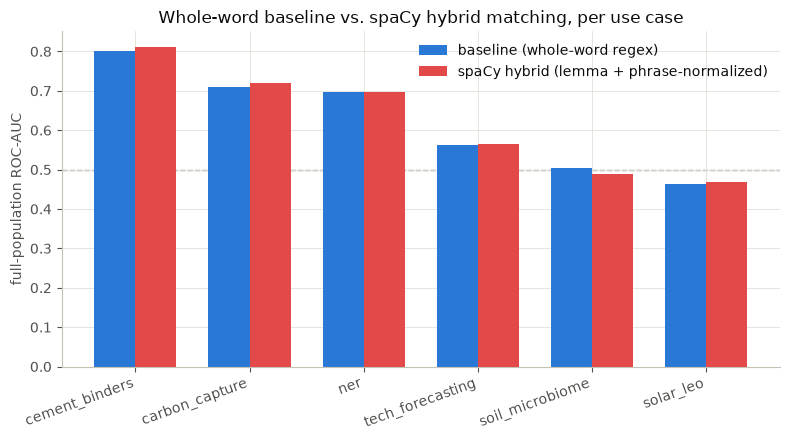

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = final.index
x = np.arange(len(order))
width = 0.36
ax.bar(x - width / 2, final.loc[order, "baseline_auc"], width, label="baseline (whole-word regex)", color=BASELINE_COLOR)
ax.bar(x + width / 2, final.loc[order, "hybrid_auc"], width, label="spaCy hybrid (lemma + phrase-normalized)", color=SPACY_COLOR)
ax.axhline(0.5, color="#8a8878", linewidth=1, linestyle="--", zorder=0)
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=20, ha="right")
ax.set_ylabel("full-population ROC-AUC")
ax.set_title("Whole-word baseline vs. spaCy hybrid matching, per use case")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 10. Verdict

**Hard numbers:** the best spaCy technique tested (hybrid surface-or-lemma matching,
§6) moves the 3 use cases that already worked by **+0.010 to +0.011** AUC
(`cement_binders` 0.801→0.811, `carbon_capture` 0.709→0.720), leaves `ner`
essentially flat (0.698→0.696, noise-level), and **rescues none** of the 3 dead use
cases — `soil_microbiome` (0.504→0.490), `solar_leo` (0.464→0.469), and
`tech_forecasting` (0.563→0.566) all remain at chance, none significant at p < 0.05.
Naive lemma matching (§5) is **not safe to use as-is** — it regressed
`cement_binders` by -0.024 AUC due to a concrete, diagnosed spaCy lemmatizer quirk
(out-of-context POS mistagging on short term phrases); the hybrid fix in §6 resolves
that and is the only lemma-based variant that's a strict improvement over plain
whole-word matching everywhere it isn't flat. Negation-aware exclude-handling (§7) is
implemented and validated to work, but made exactly zero difference on this corpus —
none of its real exclude-term mentions happen to be negated.

**Judgement call:** the honest verdict is **marginal, not transformative**. spaCy's
hybrid matching is a strict, safe upgrade over plain regex whole-word matching (never
worse, small-but-real gains of ~0.01 AUC on 2 of 6 use cases) — worth adopting if a
`spacy` dependency and ~1 minute of pipeline time per corpus is already an acceptable
cost, but it does not change which use cases this feature is useful for. The
regex-only baseline is still the right default for anyone who wants the simplest
thing that works: it captures nearly all of the same signal (within ~0.01 AUC) with
zero extra dependencies. spaCy earns its keep here only as a small refinement, not as
the reason to adopt term-overlap as a feature in the first place.